In [14]:
# Import necessary libraries
import os
import glob
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [15]:
# User Input Parameters (CHANGE)
date_str = "20260127"  # YYYYMMDD format
start_time_str = "000000"  # HHMMSS format
end_time_str = "002000"  # HHMMSS format

# Base path for acoustic data
base_path = "/Users/xylu/Desktop/Data/acoustic_vpp/"

# Convert strings to datetime objects for filtering
date_obj = datetime.strptime(date_str, "%Y%m%d")
start_time_obj = datetime.strptime(date_str + start_time_str, "%Y%m%d%H%M%S")
end_time_obj = datetime.strptime(date_str + end_time_str, "%Y%m%d%H%M%S")

print(f"Date: {date_str}")
print(f"Time range: {start_time_str} - {end_time_str}")
print(f"Start: {start_time_obj.strftime('%Y-%m-%d %H:%M:%S')}")
print(f"End: {end_time_obj.strftime('%Y-%m-%d %H:%M:%S')}")

Date: 20260127
Time range: 000000 - 002000
Start: 2026-01-27 00:00:00
End: 2026-01-27 00:20:00


In [16]:
# Load CSV files for the specified date
print("\n" + "="*60)
print("Looking for CSV files...")
print("="*60)

# Direct path: files are stored in /acoustic_vpp/YYYYMMDD/
date_folder = os.path.join(base_path, date_str)

if not os.path.exists(date_folder):
    print(f"⚠ Folder not found: {date_folder}")
    filtered_df = None
else:
    print(f"✓ Found folder: {date_folder}")
    
    # Find all CSV files matching the date pattern
    csv_files = sorted(glob.glob(os.path.join(date_folder, f"{date_str}*.csv")))
    print(f"  Found {len(csv_files)} CSV file(s)")
    
    if len(csv_files) == 0:
        print(f"⚠ No CSV files found matching {date_str}*.csv")
        filtered_df = None
    else:
        # Load and combine all CSV files
        all_data = []
        
        for csv_file in csv_files:
            try:
                df = pd.read_csv(csv_file)
                # Convert time_datetime to datetime if it's a string (handles microseconds)
                if 'time_datetime' in df.columns:
                    df['time_datetime'] = pd.to_datetime(df['time_datetime'], format='ISO8601')
                all_data.append(df)
                print(f"  ✓ {os.path.basename(csv_file)}: {len(df)} samples")
            except Exception as e:
                print(f"  ✗ Error reading {os.path.basename(csv_file)}: {e}")
        
        if all_data:
            # Combine all data
            combined_df = pd.concat(all_data, ignore_index=True)
            combined_df = combined_df.sort_values('time_datetime').reset_index(drop=True)
            
            print(f"\n✓ Combined data: {len(combined_df)} total samples")
            print(f"  Time range: {combined_df['time_datetime'].min()} to {combined_df['time_datetime'].max()}")
            
            # Filter by time range
            mask = (combined_df['time_datetime'] >= start_time_obj) & (combined_df['time_datetime'] <= end_time_obj)
            filtered_df = combined_df[mask].reset_index(drop=True)
            
            print(f"\n✓ Filtered data (between {start_time_obj.strftime('%H:%M:%S')} and {end_time_obj.strftime('%H:%M:%S')}): {len(filtered_df)} samples")
            
            if len(filtered_df) > 0:
                print(f"  Vpp range: {filtered_df['vpp_volts'].min():.4f} - {filtered_df['vpp_volts'].max():.4f} V")
            else:
                print("  ⚠ No data after filtering by time range")
        else:
            print("⚠ No data loaded!")
            filtered_df = None


Looking for CSV files...
✓ Found folder: /Users/xylu/Desktop/Data/acoustic_vpp/20260127
  Found 288 CSV file(s)
  ✓ 20260127_000000_n_vpp.csv: 6020 samples
  ✓ 20260127_000500_n_vpp.csv: 6000 samples
  ✓ 20260127_001000_n_vpp.csv: 6000 samples
  ✓ 20260127_001500_n_vpp.csv: 6000 samples
  ✓ 20260127_002000_n_vpp.csv: 6000 samples
  ✓ 20260127_002500_n_vpp.csv: 6000 samples
  ✓ 20260127_003000_n_vpp.csv: 6000 samples
  ✓ 20260127_003500_n_vpp.csv: 6000 samples
  ✓ 20260127_004000_n_vpp.csv: 6000 samples
  ✓ 20260127_004500_n_vpp.csv: 6000 samples
  ✓ 20260127_005000_n_vpp.csv: 6000 samples
  ✓ 20260127_005500_n_vpp.csv: 6000 samples
  ✓ 20260127_010000_n_vpp.csv: 6020 samples
  ✓ 20260127_010500_n_vpp.csv: 6000 samples
  ✓ 20260127_011000_n_vpp.csv: 6000 samples
  ✓ 20260127_011500_n_vpp.csv: 6000 samples
  ✓ 20260127_012000_n_vpp.csv: 6000 samples
  ✓ 20260127_012500_n_vpp.csv: 6000 samples
  ✓ 20260127_013000_n_vpp.csv: 6000 samples
  ✓ 20260127_013500_n_vpp.csv: 6000 samples
  ✓ 202

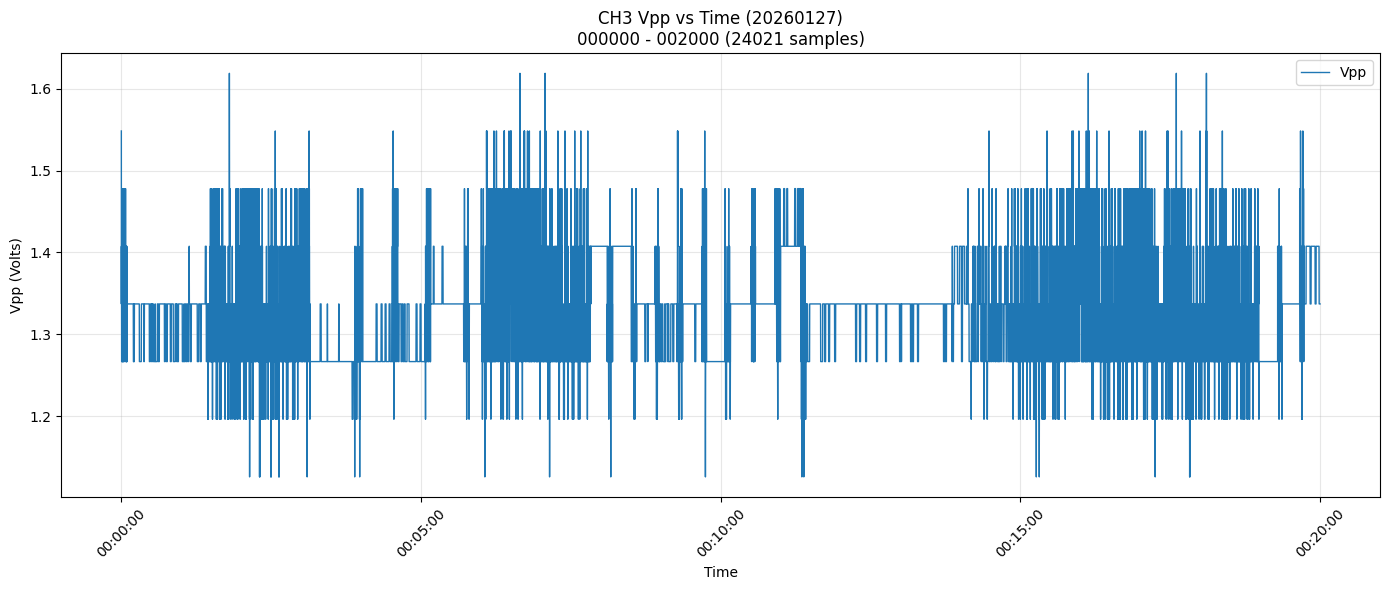


Data Statistics
Min Vpp: 1.1261 V
Max Vpp: 1.6187 V
Mean Vpp: 1.3200 V
Median Vpp: 1.3372 V
Std Dev: 0.0565 V
Total samples: 24021
Duration: 1200.0 seconds


In [17]:
# Plot Vpp vs Time
if filtered_df is not None and len(filtered_df) > 0:
    fig, ax = plt.subplots(figsize=(14, 6))
    
    ax.plot(filtered_df['time_datetime'], filtered_df['vpp_volts'], linewidth=1, label='Vpp')
    ax.set_xlabel("Time")
    ax.set_ylabel("Vpp (Volts)")
    ax.set_title(f"CH3 Vpp vs Time ({date_str})\n{start_time_str} - {end_time_str} ({len(filtered_df)} samples)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Format x-axis
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\n" + "="*60)
    print("Data Statistics")
    print("="*60)
    print(f"Min Vpp: {filtered_df['vpp_volts'].min():.4f} V")
    print(f"Max Vpp: {filtered_df['vpp_volts'].max():.4f} V")
    print(f"Mean Vpp: {filtered_df['vpp_volts'].mean():.4f} V")
    print(f"Median Vpp: {filtered_df['vpp_volts'].median():.4f} V")
    print(f"Std Dev: {filtered_df['vpp_volts'].std():.4f} V")
    print(f"Total samples: {len(filtered_df)}")
    print(f"Duration: {(filtered_df['time_datetime'].max() - filtered_df['time_datetime'].min()).total_seconds()} seconds")
else:
    print("No data to plot!")